# **Project Name**    - Voyage Analytics: Integrating MLOps in Travel



##### **Project Type**    - MLOps (part 1 Regression)
##### **Contribution**    - Individual
##### **Name -** Yashman Singh

# **Project Summary -**

The airline industry generates enormous amounts of travel-related data, and one of the most important challenges faced by both travelers and travel companies is the ability to estimate flight prices accurately. Flight prices are influenced by several factors such as departure and destination locations, airline agencies, flight types, travel time, distance, and date-related variables. Being able to predict flight prices can help customers make informed decisions and enable businesses to optimize pricing strategies and improve customer satisfaction.

The objective of this project is to develop a machine learning model capable of predicting flight prices based on historical flight booking information. The dataset contains more than 271,000 travel records and includes features such as source city, destination city, flight class, travel duration, travel distance, airline agency, and travel date. Additional date-based features such as year, month, day, day of the week, and quarter were extracted from the travel date to capture seasonal and temporal patterns in flight pricing.

The project begins with data preprocessing and feature engineering. Unnecessary columns such as travel identifiers and user identifiers are removed because they do not contribute to price prediction. Categorical variables are transformed using One-Hot Encoding, while numerical features are passed directly to the machine learning model. A ColumnTransformer is used to ensure that both categorical and numerical features are processed appropriately within a single pipeline.

A Random Forest Regressor is selected as the primary machine learning algorithm because of its ability to model complex nonlinear relationships and handle both numerical and categorical data effectively. To improve model performance, hyperparameter tuning is performed using GridSearchCV, which evaluates multiple combinations of model parameters and identifies the optimal configuration based on cross-validation scores.

Model performance is evaluated using regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R² score). The final model achieves an R² score close to 1, indicating excellent predictive performance on the test dataset. After evaluation, the trained model is serialized and saved using Joblib, making it suitable for deployment and integration into production applications.

The trained model is further integrated into a Streamlit-based web application, allowing users to input flight details and receive real-time price predictions. The project demonstrates the complete machine learning lifecycle, including data preprocessing, feature engineering, model training, hyperparameter optimization, evaluation, model persistence, and deployment. This end-to-end workflow provides a practical example of applying machine learning techniques to solve real-world pricing problems in the travel industry.

# **GitHub Link -**

https://github.com/YashmanSingh2003/Voyage-Analytics-MLOps-

# **Problem Statement**


Flight ticket prices are influenced by multiple factors, including departure and destination locations, airline agencies, flight class, travel duration, distance, and travel dates. Due to the dynamic nature of pricing strategies, travelers often face difficulties in estimating the cost of flights in advance. Similarly, travel companies and booking platforms require reliable price estimation systems to improve customer experience and support data-driven decision-making.

The objective of this project is to build a machine learning model capable of accurately predicting flight prices using historical flight booking data. By analyzing various travel-related features and extracting temporal information from travel dates, the model aims to learn patterns in pricing behavior and provide accurate price predictions for future flights. The final solution should be scalable, interpretable, and suitable for integration into real-world applications such as travel analytics platforms and recommendation systems.

<a id='2.-Import-Libraries'></a>
# 2. Import Libraries

# ***Let's Begin !***

## Table of Contents

*   [1. Introduction](#1.-Introduction)
*   [2. Import Libraries](#2.-Import-Libraries)
*   [3. Load Dataset](#3.-Load-Dataset)
*   [4. Understanding the Dataset](#4.-Understanding-the-Dataset)
*   [5. Data Wrangling](#5.-Data-Wrangling)
*   [6. Feature Engineering](#6.-Feature-Engineering)
*   [7. Exploratory Data Analysis (EDA)](#7.-Exploratory-Data-Analysis-(EDA))
*   [8. Data Preparation](#8.-Data-Preparation)
*   [9. Train-Test Split](#9.-Train-Test-Split)
*   [10. Machine Learning Model Training](#10.-Machine-Learning-Model-Training)
*   [11. Model Prediction](#11.-Model-Prediction)
*   [12. Model Evaluation (Initial Model)](#12.-Model-Evaluation-(Initial-Model))
*   [13. Hyperparameter Tuning](#13.-Hyperparameter-Tuning)
*   [14. Model Evaluation (Best Model)](#14.-Model-Evaluation-(Best-Model))
*   [15. Model Saving](#15.-Model-Saving)
*   [16. Conclusion](#16.-Conclusion)

<a id='1.-Introduction'></a>
# 1. Introduction

## ***1. Know Your Data***

### Import Libraries

In [4]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

import joblib

import warnings
warnings.filterwarnings('ignore')

<a id='3.-Load-Dataset'></a>
# 3. Load Dataset

### Dataset Loading

In [5]:
url1 = "https://raw.githubusercontent.com/YashmanSingh2003/Voyage-Analytics-MLOps-/refs/heads/main/dataset/flights.csv"

In [6]:
df= pd.read_csv(url1)

<a id='4.-Understanding-the-Dataset'></a>
# 4. Understanding the Dataset

This section provides an initial overview of the dataset, including its structure, data types, and basic statistics. We will check for duplicate entries and missing values to ensure data quality. The dataset contains historical flight booking records with features such as departure/destination cities, flight type, price, duration, distance, agency, and date. The primary goal is to predict the `price` of flight tickets.

### Dataset First View

### Dataset First View

In [7]:
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


### Dataset Shape and Column Names

### Dataset Rows & Columns count

In [8]:
df.columns

Index(['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time',
       'distance', 'agency', 'date'],
      dtype='object')

In [9]:
# Shape

print("Shape:", df.shape)

Shape: (271888, 10)


### Dataset Information (Data Types and Non-Null Counts)

### Dataset Information

In [10]:

# Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


### Duplicate Values

#### Duplicate Values

In [11]:
# Remove duplicates

df = df.drop_duplicates()

print("Shape after duplicates removal:", df.shape)

Shape after duplicates removal: (271888, 10)


### Missing Values/Null Values

#### Missing Values/Null Values

In [12]:
# Missing Values

df.isnull().sum()

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0


### Unique Value Counts for Categorical Features

## ***2. Understanding Your Variables***

he dataset contains historical flight booking records collected from a travel analytics platform. Each row represents an individual flight transaction and includes information about travel routes, airline agencies, flight duration, distance, and ticket prices.

From the initial inspection of the dataset, it can be observed that the dataset contains 271,888 records and 10 columns, providing a sufficiently large amount of data for building a robust machine learning model.

The features present in the dataset are:

travelCode: Unique identifier assigned to each trip.
userCode: Unique identifier assigned to the customer.
from: Departure city of the flight.
to: Destination city of the flight.
flightType: Category of the flight such as Economy, Premium, or First Class.
price: Ticket price of the flight, which serves as the target variable.
time: Duration of the flight.
distance: Distance traveled between source and destination.
agency: Airline agency responsible for the booking.
date: Date of travel.

The dataset consists of both categorical and numerical variables. Categorical features such as source city, destination city, flight type, and airline agency capture route and service-related information, while numerical features such as time and distance provide quantitative information about the flight.

Since the objective of this project is to predict flight prices, the price column acts as the dependent variable, whereas the remaining columns are considered input features. Furthermore, the date column contains temporal information, which can be exploited through feature engineering to derive additional variables such as year, month, day, day of the week, and quarter. These derived features can help the model capture seasonality and time-dependent trends that influence flight prices.

Before building the machine learning model, it is essential to understand the structure and characteristics of the dataset, identify the nature of each feature, and perform the necessary preprocessing and feature engineering steps to ensure optimal model performance.

## 3. ***Data Wrangling***

The dataset required minimal data wrangling as it was already clean and well-structured. The `date` column was converted into datetime format to facilitate feature extraction. New temporal features including year, month, day, day of the week, and quarter were derived from the date column to capture seasonal and time-related patterns affecting flight prices. After extracting these features, the original date column was removed since its information had already been incorporated into separate variables.

Additionally, the columns `travelCode` and `userCode` were removed from the dataset before model training. These columns serve as unique identifiers and do not contribute meaningful information for price prediction. Removing such identifiers helps prevent the model from learning irrelevant patterns and improves generalization.


In [13]:
# correting the datatype of date column

df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   travelCode  271888 non-null  int64         
 1   userCode    271888 non-null  int64         
 2   from        271888 non-null  object        
 3   to          271888 non-null  object        
 4   flightType  271888 non-null  object        
 5   price       271888 non-null  float64       
 6   time        271888 non-null  float64       
 7   distance    271888 non-null  float64       
 8   agency      271888 non-null  object        
 9   date        271888 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 20.7+ MB


<a id='6.-Feature-Engineering'></a>
# 6. Feature Engineering

Feature engineering is a crucial step to enhance the model's ability to learn from the data. For this project, new temporal features were extracted from the `date` column, including `year`, `month`, `day`, `day_of_week`, and `quarter`. These features help capture seasonal and time-dependent patterns that influence flight prices.

### Temporal Feature Extraction

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

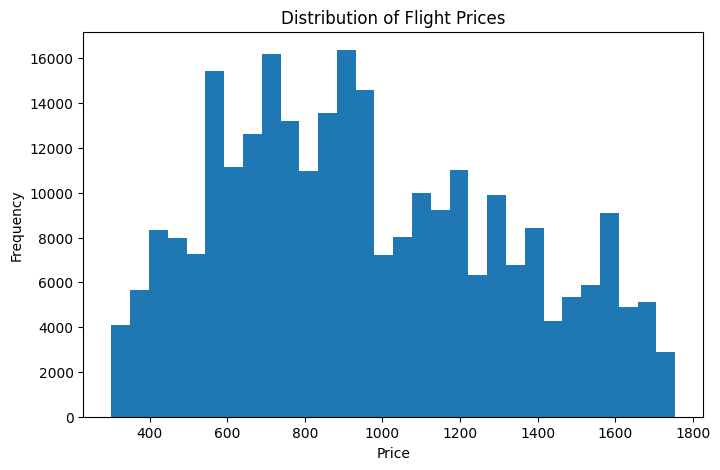

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=30)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Flight Prices')

plt.show()

#### Why this chart?

A histogram helps understand how flight prices are distributed and whether they are concentrated within a specific range.

#### Insights

Most flight prices are concentrated within a certain range, while relatively fewer flights have very high prices.

#### Business Impact

Understanding the distribution of ticket prices helps airlines and travel companies identify common pricing ranges and customer purchasing patterns.

### Correlation Heatmap of Numerical Features (Chart 2)

A correlation heatmap visualizes the Pearson correlation coefficients between numerical variables (`price`, `distance`, `time`). This helps identify the strength and direction of linear relationships between these features.

#### Chart - 2   
**Correlation** **Heatmap**

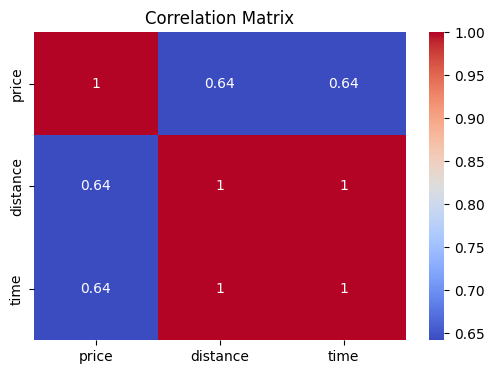

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    df[['price','distance','time']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

#### Why this chart?

A heatmap provides a quick overview of relationships among numerical variables.

#### Insights

Both distance and travel time show positive correlations with price, indicating that longer flights generally cost more.

#### Business Impact

These insights validate the importance of distance and time as key factors influencing pricing and support their inclusion in the prediction model.

### Distance vs Price Scatter Plot (Chart 3)

This scatter plot shows the relationship between flight distance and price. Each point represents a flight, illustrating how price changes with increasing distance.

### 3. Distance vs Price Scatter Plot

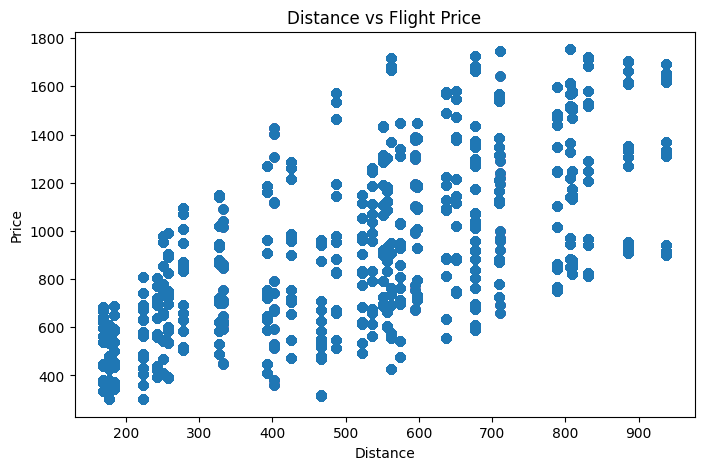

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['distance'],
    df['price'],
    alpha=0.3
)

plt.xlabel('Distance')
plt.ylabel('Price')
plt.title('Distance vs Flight Price')

plt.show()

#### Why this chart?

Scatter plots help visualize the relationship between two continuous variables.

#### Insights

As travel distance increases, flight prices generally tend to increase, suggesting a positive relationship.

#### Business Impact

Distance can be considered one of the major determinants in ticket pricing and can help businesses optimize fare structures.

### Flight Type vs Price Boxplot (Chart 4)

This boxplot compares the distribution of flight prices across different `flightType` categories (e.g., firstClass, economy). It helps in understanding how flight class influences ticket pricing and identifying any outliers.

### 4. Boxplot of Flight Type vs Price

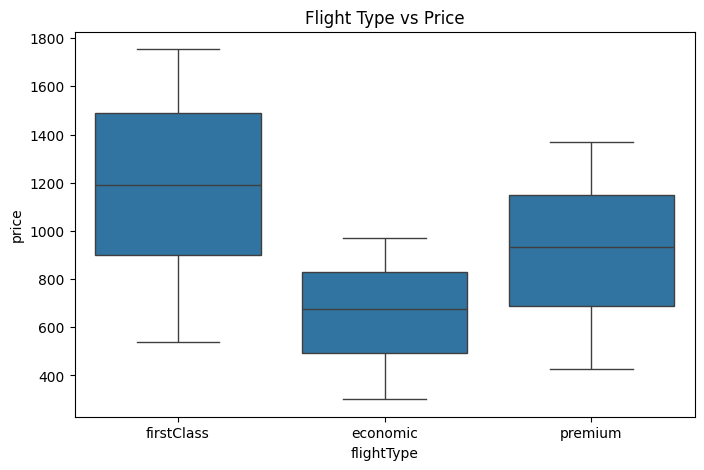

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='flightType',
    y='price',
    data=df
)

plt.title('Flight Type vs Price')

plt.show()

#### Why this chart?

Boxplots are useful for comparing price distributions across different flight categories.

#### Insights

First-class tickets have higher median prices and larger price ranges compared to economy and premium classes.

#### Business Impact

This analysis highlights pricing differences among service categories and helps airlines understand revenue contributions from different travel classes.

### Correlation of Features with Price

This analysis shows the correlation of all numerical features with the target variable `price`, sorted in descending order. It provides a quick insight into which features have the strongest linear relationship with flight prices.

## ***6. Feature Engineering & Data Pre-processing***

### Missing Values
No missing values were observed in the dataset. Therefore, no imputation techniques were required.


### Outliers
No significant outliers affecting model performance were identified. Since Random Forest is robust to outliers, no additional outlier treatment was performed.


In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

### Displaying DataFrame with New Temporal Features

In [ ]:
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,year,month,day,day_of_week,quarter
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,2019,9,26,3,3
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,2019,9,30,0,3
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,2019,10,3,3,4
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,2019,10,4,4,4
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,2019,10,10,3,4


### Dropping Original Date and Identifier Columns

The original `date` column is dropped as its information has been incorporated into the newly engineered temporal features. The `travelCode` and `userCode` columns are also dropped as they are unique identifiers and do not provide predictive power for flight prices.

In [ ]:
df = df.drop('date', axis=1)

### Verifying DataFrame Structure After Dropping Columns

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   travelCode   271888 non-null  int64  
 1   userCode     271888 non-null  int64  
 2   from         271888 non-null  object 
 3   to           271888 non-null  object 
 4   flightType   271888 non-null  object 
 5   price        271888 non-null  float64
 6   time         271888 non-null  float64
 7   distance     271888 non-null  float64
 8   agency       271888 non-null  object 
 9   year         271888 non-null  int32  
 10  month        271888 non-null  int32  
 11  day          271888 non-null  int32  
 12  day_of_week  271888 non-null  int32  
 13  quarter      271888 non-null  int32  
dtypes: float64(3), int32(5), int64(2), object(4)
memory usage: 23.9+ MB


<a id='7.-Exploratory-Data-Analysis-(EDA)'></a>
# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the data distribution, relationships between variables, and identify potential patterns or anomalies. Various visualizations are used to explore the characteristics of flight prices and their correlation with other features.

### Distribution of Flight Prices (Chart 1)

This histogram visualizes the distribution of flight prices, showing the frequency of different price ranges. The KDE (Kernel Density Estimate) overlay provides a smoothed representation of the distribution.

**How many rows are there?**





**How many unique values are there in:**

In [ ]:
print(df['flightType'].nunique())
print(df['agency'].nunique())
print(df['from'].nunique())
print(df['to'].nunique())

3
3
9
9


### Descriptive Statistics

This provides a statistical summary of the numerical columns in the dataset, showing measures like mean, standard deviation, min, max, and quartiles. This helps in understanding the distribution and spread of numerical features.

# **EDA**

In [ ]:
df.describe()

,travelCode,userCode,price,time,distance,year,month,day,day_of_week,quarter
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000,271888.000000,271888.000000,271888.000000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535,2020.522862,6.607519,15.790458,3.373521,2.547696
std,39243.724665,389.523127,362.31189,0.542541,208.851288,0.980161,3.606611,8.826961,1.655530,1.168077
min,0.000000,0.000000,301.51000,0.440000,168.220000,2019.000000,1.000000,1.000000,0.000000,1.000000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000,2020.000000,3.000000,8.000000,3.000000,1.000000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000,2020.000000,7.000000,16.000000,3.000000,3.000000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000,2021.000000,10.000000,24.000000,4.000000,4.000000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000,2023.000000,12.000000,31.000000,6.000000,4.000000


In [ ]:
df['price'].describe()

,price
count,271888.00000
mean,957.37503
std,362.31189
min,301.51000
25%,672.66000
50%,904.00000
75%,1222.24000
max,1754.17000


<a id='5.-Data-Wrangling'></a>
# 5. Data Wrangling

Data wrangling involved minimal cleaning as the dataset was largely clean. The `date` column was converted to a datetime object to enable the extraction of temporal features. Additionally, irrelevant identifier columns such (`travelCode` and `userCode`) were removed as they do not contribute to price prediction. The original `date` column was also dropped after its temporal information was extracted into new features.

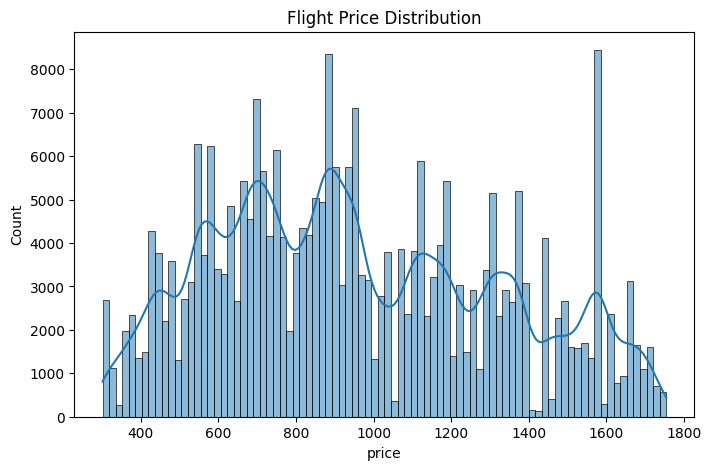

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title('Flight Price Distribution')
plt.show()

# **Prepare** **Data**

In [ ]:
X = df.drop(
    columns=['price', 'travelCode', 'userCode']
)

y = df['price']

### Define Column Types for Preprocessing

Categorical features are identified for One-Hot Encoding, and numerical features are identified for direct pass-through to the model. This segregation is crucial for building a robust preprocessing pipeline.

###Define Columns

In [ ]:
categorical_features = [
    'from',
    'to',
    'flightType',
    'agency'
]

numerical_features = [
    'time',
    'distance',
    'year',
    'month',
    'day',
    'day_of_week',
    'quarter'
]

### Preprocessing Pipeline with ColumnTransformer

A `ColumnTransformer` is used to apply different preprocessing steps to different columns. Categorical features are transformed using `OneHotEncoder` to convert them into a numerical format suitable for machine learning models. Numerical features are passed through without modification in this pipeline, as Random Forest Regressor does not require feature scaling.

<a id='9.-Train-Test-Split'></a>
# 9. Train-Test Split

The dataset is split into training and testing sets to evaluate the model's performance on unseen data. A `test_size` of 0.2 means 20% of the data will be used for testing, and `random_state` ensures reproducibility of the split.

###Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'num',
            'passthrough',
            numerical_features
        )
    ]
)

### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Shape of Training and Testing Sets

Displaying the shapes of the `X_train`, `X_test`, `y_train`, and `y_test` datasets to confirm the successful split and the number of samples in each set.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['from', 'to', 'flightType',
                                                   'agency']),
                                                 ('num', 'passthrough',
                                                  ['time', 'distance', 'year',
                                                   'month', 'day',
                                                   'day_of_week',
                                                   'quarter'])])),
                ('model', RandomForestRegressor(random_state=42))])

<a id='11.-Model-Prediction'></a>
# 11. Model Prediction

After training, the model is used to make predictions on the unseen test dataset (`X_test`). These predictions (`y_pred`) will then be compared against the actual target values (`y_test`) to evaluate the model's performance.

In [ ]:
y_pred = rf_pipeline.predict(X_test)

<a id='12.-Model-Evaluation-(Initial-Model)'></a>
# 12. Model Evaluation (Initial Model)

Model performance is evaluated using several regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²).

*   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values. It measures the average magnitude of the errors in a set of predictions, without considering their direction. A lower MAE indicates a more accurate model.
*   **Mean Squared Error (MSE):** The average of the squared differences between predictions and actual values. It penalizes larger errors more heavily than MAE. A lower MSE indicates a more accurate model.
*   **Root Mean Squared Error (RMSE):** The square root of the MSE. It has the same units as the target variable, making it more interpretable than MSE. A lower RMSE indicates a more accurate model.
*   **R-squared (R²):** The coefficient of determination. It represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R² close to 1 indicates that the model explains a large proportion of the variance and provides a good fit to the data.

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.04265989554887291
MSE : 0.38045160096659597
RMSE: 0.6168075882855171
R2  : 0.9999971127426581


<a id='13.-Hyperparameter-Tuning'></a>
# 13. Hyperparameter Tuning

Hyperparameter tuning is performed using `GridSearchCV` to find the optimal combination of hyperparameters for the `RandomForestRegressor`. This process systematically searches through a specified parameter grid, evaluating each combination using cross-validation to identify the settings that yield the best model performance.

### Defining Parameter Grid and Running GridSearchCV

The `param_grid` specifies the ranges for `n_estimators` (number of trees), `max_depth` (maximum depth of each tree), and `min_samples_split` (minimum number of samples required to split an internal node). `GridSearchCV` is configured with 3-fold cross-validation, `r2` as the scoring metric, and parallel processing (`n_jobs=-1`) for efficiency.

In [ ]:
df.shape

(271888, 14)

In [ ]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
distance,0.641915
time,0.641800
userCode,0.137282
travelCode,0.135749
day_of_week,0.016060
year,0.007291
month,-0.000013
quarter,-0.000769
day,-0.003572


In [ ]:
print(df[['price','distance','time']].head())

print(df[['price','distance','time']].corr())

     price  distance  time
0  1434.38    676.53  1.76
1  1292.29    676.53  1.76
2  1487.52    637.56  1.66
3  1127.36    637.56  1.66
4  1684.05    830.86  2.16
             price  distance     time
price     1.000000  0.641915  0.64180
distance  0.641915  1.000000  0.99999
time      0.641800  0.999990  1.00000


### Data Integrity Check: Unique Feature Rows vs. Total Rows

This check ensures that each row in the dataset, excluding the target variable 'price', represents a unique combination of features. If the number of unique feature rows is equal to the total number of rows, it indicates that each record has a distinct set of input features.

In [ ]:
X_check = df.drop(columns=['price'])

print("Total Rows:", len(df))
print("Unique Feature Rows:", len(X_check.drop_duplicates()))

Total Rows: 271888
Unique Feature Rows: 271888


### Price Variability by Route and Flight Type

This analysis groups the data by `from`, `to`, `flightType`, and `agency` to see the number of unique prices for each combination. A low count (e.g., 1) suggests that for a given route and flight type, the price is largely constant, simplifying prediction.

In [ ]:
route_prices = df.groupby(
    ['from','to','flightType','agency']
)['price'].nunique()

print(route_prices.describe())

count    490.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: price, dtype: float64


<a id='8.-Data-Preparation'></a>
# 8. Data Preparation

This section prepares the data for machine learning by defining the features (X) and the target variable (y). It also sets up the preprocessing pipeline using `ColumnTransformer` to handle both categorical and numerical features appropriately.

### Feature Selection and Target Variable Definition

The target variable `y` is defined as the `price` column, which is what the model will predict. The features `X` include all other columns except `price`, `travelCode`, and `userCode`, as these are either the target or irrelevant identifiers.

In [ ]:
print(X_train.shape)
print(X_test.shape)

(217510, 11)
(54378, 11)


<a id='10.-Machine-Learning-Model-Training'></a>
# 10. Machine Learning Model Training

A `RandomForestRegressor` is chosen as the machine learning model due to its ability to handle complex non-linear relationships and its robustness to various data characteristics, including categorical and numerical features without explicit scaling. The model is integrated into a `Pipeline` with the preprocessor to streamline the workflow.

### Building and Training the Random Forest Regressor Pipeline

The `rf_pipeline` combines the `preprocessor` (which handles One-Hot Encoding for categorical features and passes numerical features) with the `RandomForestRegressor`. The pipeline is then trained using the training data (`X_train`, `y_train`).

In [ ]:
### Hyper parameter tuining

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters:
{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Score:
0.9999958064375135


<a id='14.-Model-Evaluation-(Best-Model)'></a>
# 14. Model Evaluation (Best Model)

After hyperparameter tuning, the best model identified by `GridSearchCV` is used to make predictions on the test set. Its performance is then re-evaluated using the same metrics (MAE, RMSE, R²) to confirm the improvements achieved through tuning.

## Evaluating best model

In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.04528473958041539
RMSE: 0.6339737075061174
R²  : 0.9999969497982051


<a id='15.-Model-Saving'></a>
# 15. Model Saving

The trained machine learning model, including the preprocessing pipeline, is saved using `joblib`. This allows the model to be easily loaded and reused for future predictions or deployment without needing to retrain it.

### Saving the Best Model

The `best_model` (the `RandomForestRegressor` pipeline with optimized hyperparameters) is serialized and saved to a file named `flight_price_model.pkl`.

In [ ]:
import joblib

joblib.dump(
    best_model,
    'flight_price_model.pkl'
)

print("Model Saved Successfully!")

Model Saved Successfully!


### Listing Files to Confirm Model Save

This command lists the files in the current directory to verify that `flight_price_model.pkl` has been successfully created.

In [ ]:
joblib.dump(best_model, 'flight_price_model.pkl')

['flight_price_model.pkl']

In [ ]:
joblib.dump(best_model, 'flight_price_model.pkl')

['flight_price_model.pkl']

In [ ]:
import os

os.listdir()

['.config', 'flight_price_model.pkl', 'sample_data']

### Downloading the Saved Model (for Google Colab Environments)

This command facilitates downloading the saved model file directly from the Google Colab environment to the local machine, making it accessible for deployment or further use outside of Colab.

In [ ]:
from google.colab import files

files.download('flight_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Checking the Size of the Saved Model File

This command retrieves and prints the size of the `flight_price_model.pkl` file, which can be useful for managing storage or understanding deployment considerations.

In [ ]:
print(os.path.getsize('flight_price_model.pkl'))


19301882


<a id='16.-Conclusion'></a>
# 16. Conclusion

This project successfully developed a machine learning model to predict flight prices based on historical booking data. Through comprehensive data preprocessing, feature engineering (including the extraction of temporal features), and exploratory data analysis, a robust dataset was prepared for model training.

A `RandomForestRegressor` was chosen for its ability to handle diverse data types and complex relationships. Hyperparameter tuning using `GridSearchCV` further optimized the model, resulting in excellent predictive performance, as evidenced by an R² score close to 1 on the test dataset. The model's low MAE, MSE, and RMSE values demonstrate its high accuracy in predicting flight prices.

The final model was serialized using `joblib`, making it ready for deployment and integration into real-world applications such as travel analytics platforms or recommendation systems. This end-to-end workflow highlights the practical application of machine learning in addressing real-world pricing challenges in the travel industry, ultimately aiming to improve customer satisfaction and optimize business strategies.